In [3]:
import os
import numpy as np
import torch
import cv2
import warnings
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# ==============================================================================
# 1. 准备工作 (保持不变)
# ==============================================================================
try:
    from networks.vit_seg_modeling import VisionTransformer as ViT_seg, CONFIGS
except ImportError:
    raise ImportError("错误: 无法导入 TransUNet 模型。请确保 'networks/vit_seg_modeling.py' 文件存在。")

# ==============================================================================
# 2. 用户配置区域 (您只需要修改这里)
# ==============================================================================

# --- 必填 1: 指定您预训练好的 TransUNet 模型权重文件路径 ---
MODEL_CKPT_PATH = '/home/zhengsongming/jupyterworkspace/03医学图像分割/TransUnet_demo/TransUNet/model_busi/TU_BUSI224_pretrain_R50-ViT-B_16_skip3_epo100_bs24_224/epoch_99.pth'

# --- 必填 2: 指定您的数据集根目录 ---
SPLIT_DATASET_ROOT = "/home/zhengsongming/jupyterworkspace/datasets/BUSI_for_SAM2" 

# --- 必填 3: 指定您想要可视化的样本名列表 ---
SAMPLES_TO_VISUALIZE = [
    "malignant_186",
    "malignant_187",
    "malignant_188",
    "malignant_189",
    "benign_187",
    "benign_188",
]
# SAMPLES_TO_VISUALIZE = ["isic_ISIC_0000000", "isic_ISIC_0000001", "isic_ISIC_0000003", "isic_ISIC_0000004"]
# SAMPLES_TO_VISUALIZE = ["cvc_172", "cvc_296", "cvc_149", "cvc_89"]

# --- 必填 4: 模型结构参数 (必须与您训练时使用的模型结构完全一致) ---
MODEL_NAME = "TransUnet"
IMAGE_SIZE = 224
VIT_NAME = 'R50-ViT-B_16'
VIT_PATCHES_SIZE = 16
N_CLASSES = 2
N_SKIP = 3

# --- 可选 5: 指定最终组合图的保存路径和文件名 ---
# 保存目录会自动创建
VISUALIZATION_SAVE_DIR = "/home/zhengsongming/jupyterworkspace/03医学图像分割/visualizations_all/transunet_grid"
GRID_IMAGE_FILENAME = "comparison_grid.png"


# ==============================================================================
# 3. TransUNet 推理与指标计算函数 (保持不变)
# ==============================================================================

def run_inference(model, image_path, device):
    """对单张图片执行模型推理"""
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_LINEAR)
    img_tensor = torch.from_numpy(img_resized).permute(2, 0, 1).float() / 255.0
    img_tensor = (img_tensor - 0.5) / 0.5
    img_tensor = img_tensor.unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
    if isinstance(output, (list, tuple)):
        output = output[0]
    pred_mask_tensor = torch.argmax(torch.softmax(output, dim=1), dim=1).squeeze(0)
    pred_mask_np = pred_mask_tensor.cpu().numpy().astype(np.uint8)
    return pred_mask_np

def calculate_hd95_from_np(gt_mask, pred_mask):
    """从Numpy数组计算HD95"""
    gt_contours, _ = cv2.findContours(gt_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    pred_contours, _ = cv2.findContours(pred_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not gt_contours or not pred_contours: return np.nan
    gt_points = np.vstack([c.squeeze(axis=1) for c in gt_contours])
    pred_points = np.vstack([c.squeeze(axis=1) for c in pred_contours])
    dist_pred_to_gt = cdist(pred_points, gt_points, 'euclidean').min(axis=1)
    dist_gt_to_pred = cdist(gt_points, pred_points, 'euclidean').min(axis=1)
    return max(np.percentile(dist_pred_to_gt, 95), np.percentile(dist_gt_to_pred, 95))

def calculate_metrics_from_np(gt_mask_np, pred_mask_np):
    """从Numpy数组计算Dice和HD95"""
    gt_bool, pred_bool = gt_mask_np > 0, pred_mask_np > 0
    dice_score = 0.0
    if np.any(gt_bool) or np.any(pred_bool):
        dice_score = (2. * np.logical_and(gt_bool, pred_bool).sum()) / (gt_bool.sum() + pred_bool.sum())
    hd95_score = calculate_hd95_from_np(gt_mask_np, pred_mask_np)
    return {'dice': dice_score, 'hd95': hd95_score}

# ==============================================================================
# 4. 核心功能: 创建并保存组合对比图 (新)
# ==============================================================================

def create_comparison_grid(results_data, save_path):
    """
    接收所有处理好的样本数据，生成一个大的网格对比图，并以高分辨率保存。

    Args:
        results_data (list): 包含每个样本数据的字典列表。
                             每个字典格式为: {'name', 'image', 'gt', 'pred', 'metrics'}
        save_path (str): 最终组合图的完整保存路径。
    """
    num_samples = len(results_data)
    if num_samples == 0:
        print("没有可供可视化的样本。")
        return

    # 每个样本展示4张图: 原图, GT叠加, 预测对比, 误差图
    num_cols = 4
    
    # 动态调整图像大小以获得更好的视觉效果
    fig, axes = plt.subplots(num_samples, num_cols, figsize=(num_cols * 4, num_samples * 4.2))
    # 如果只有一个样本，axes不是二维数组，需要手动转换
    if num_samples == 1:
        axes = np.array([axes])
        
    plt.rc('font', size=12)  # 设置字体大小

    # --- 设置列标题 ---
    col_titles = ["Original Image", "Ground Truth Overlay", "Prediction vs. GT", "Error Map"]
    for ax, title in zip(axes[0], col_titles):
        ax.set_title(title, fontsize=16, pad=10)

    # --- 逐行填充每个样本的可视化结果 ---
    for i, data in enumerate(results_data):
        img = data['image']
        gt_mask = data['gt']
        pred_mask = data['pred']
        metrics = data['metrics']
        sample_name = data['name']

        gt_bool = gt_mask > 0
        pred_bool = pred_mask > 0

        # --- a) 原图 ---
        ax = axes[i, 0]
        ax.imshow(img)
        # 将样本名作为行标题
        ax.set_ylabel(sample_name, fontsize=14, labelpad=10, rotation=0, ha='right', va='center')


        # --- b) GT叠加图 ---
        ax = axes[i, 1]
        ax.imshow(img)
        ax.imshow(gt_bool, cmap='viridis', alpha=0.6)

        # --- c) 预测 vs. GT 轮廓对比图 ---
        ax = axes[i, 2]
        ax.imshow(img)
        ax.contour(gt_bool, colors='yellow', linewidths=1.5)
        ax.contour(pred_bool, colors='magenta', linewidths=1.5)
        # 在图上添加指标文本
        metrics_text = f"Dice: {metrics['dice']:.3f}\nHD95: {metrics['hd95']:.2f}"
        ax.text(5, 5, metrics_text, color='white', fontsize=11,
                bbox=dict(facecolor='black', alpha=0.7, boxstyle='round,pad=0.3'))

        # --- d) 误差图 (TP: Green, FN: Red, FP: Blue) ---
        ax = axes[i, 3]
        error_map = np.zeros_like(img)
        error_map[np.where((pred_bool == 1) & (gt_bool == 1))] = [0, 255, 0]  # TP - 绿色
        error_map[np.where((pred_bool == 0) & (gt_bool == 1))] = [255, 0, 0]  # FN - 红色
        error_map[np.where((pred_bool == 1) & (gt_bool == 0))] = [0, 0, 255]  # FP - 蓝色
        ax.imshow(error_map)

    # --- 统一关闭所有子图的坐标轴 ---
    for ax in axes.flat:
        ax.axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.97]) # 调整布局以适应主标题
    fig.suptitle(f"{MODEL_NAME} - Segmentation Results", fontsize=20)
    
    # --- 以300 DPI保存最终的组合图 ---
    print(f"\n正在保存组合对比图至: {save_path}")
    fig.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
    plt.close(fig)
    print("✅ 组合图保存成功！")


# ==============================================================================
# 5. 主执行逻辑
# ==============================================================================
if __name__ == '__main__':
    warnings.filterwarnings("ignore")
    print(f"--- 开始执行 {MODEL_NAME} 推理与可视化脚本 ---")

    # --- 路径和环境检查 ---
    if not os.path.exists(MODEL_CKPT_PATH):
        raise FileNotFoundError(f"错误: 模型权重文件未找到 '{MODEL_CKPT_PATH}'。")
    if not os.path.isdir(SPLIT_DATASET_ROOT):
        raise NotADirectoryError(f"错误: 数据集目录未找到 '{SPLIT_DATASET_ROOT}'。")
    os.makedirs(VISUALIZATION_SAVE_DIR, exist_ok=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用设备: {device}")

    # --- 模型加载 ---
    config_vit = CONFIGS.get(VIT_NAME)
    if config_vit is None:
        raise ValueError(f"错误: 无效的 VIT_NAME '{VIT_NAME}'。")
    config_vit.n_classes = N_CLASSES
    config_vit.n_skip = N_SKIP
    if 'R50' in VIT_NAME:
        config_vit.patches.grid = (int(IMAGE_SIZE / VIT_PATCHES_SIZE), int(IMAGE_SIZE / VIT_PATCHES_SIZE))
    
    model = ViT_seg(config_vit, img_size=IMAGE_SIZE, num_classes=config_vit.n_classes).to(device)
    
    print(f"正在从 '{MODEL_CKPT_PATH}' 加载模型权重...")
    model.load_state_dict(torch.load(MODEL_CKPT_PATH, map_location=device))
    print("模型加载成功！")

    # --- 逐个处理样本并收集结果 ---
    results_for_grid = []
    print("\n--- 正在处理指定的样本 ---")
    for sample_name in SAMPLES_TO_VISUALIZE:
        print(f"处理样本: {sample_name}...")

        image_path = os.path.join(SPLIT_DATASET_ROOT, "JPEGImages", sample_name, "00000.jpg")
        gt_mask_path = os.path.join(SPLIT_DATASET_ROOT, "Annotations", sample_name, "00000.png")

        if not (os.path.exists(image_path) and os.path.exists(gt_mask_path)):
            print(f"⚠️  警告: 找不到 {sample_name} 的图像或掩码，已跳过。")
            continue
        
        # 1. 执行推理，得到预测掩码
        pred_mask_np = run_inference(model, image_path, device)

        # 2. 加载原图和GT掩码，并统一 resize 到目标尺寸
        original_img_rgb = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
        gt_mask_gray = cv2.imread(gt_mask_path, cv2.IMREAD_GRAYSCALE)
        
        img_resized = cv2.resize(original_img_rgb, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_LINEAR)
        gt_mask_resized = cv2.resize(gt_mask_gray, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_NEAREST)
        
        # 确保GT掩码是二值的 (0或1)
        _, gt_mask_binary = cv2.threshold(gt_mask_resized, 127, 255, cv2.THRESH_BINARY)
        gt_mask_np = (gt_mask_binary / 255).astype(np.uint8)

        # 3. 计算指标
        metrics = calculate_metrics_from_np(gt_mask_np, pred_mask_np)
        print(f"  -> 指标: Dice={metrics['dice']:.4f}, HD95={metrics['hd95']:.2f}")

        # 4. 将该样本的所有处理结果打包存入列表
        results_for_grid.append({
            'name': sample_name,
            'image': img_resized,
            'gt': gt_mask_np,
            'pred': pred_mask_np,
            'metrics': metrics
        })

    # --- 所有样本处理完毕后，调用函数生成并保存最终的组合图 ---
    if results_for_grid:
        final_save_path = os.path.join(VISUALIZATION_SAVE_DIR, GRID_IMAGE_FILENAME)
        create_comparison_grid(results_for_grid, final_save_path)

    print("\n--- 所有指定的样本已处理完毕 ---")

ImportError: 错误: 无法导入 TransUNet 模型。请确保 'networks/vit_seg_modeling.py' 文件存在。

Starting visualization process...


Visualizing samples:   0%|          | 0/2 [00:00<?, ?it/s]


--- Processing: malignant_186 ---
Running inference for Our Model (Adapter + U-BL)...
Individual sub-maps saved for malignant_186 in ./plots/
Combined diagnostic visualization saved to: ./plots/malignant_186_00000_diagnostic_combined.png


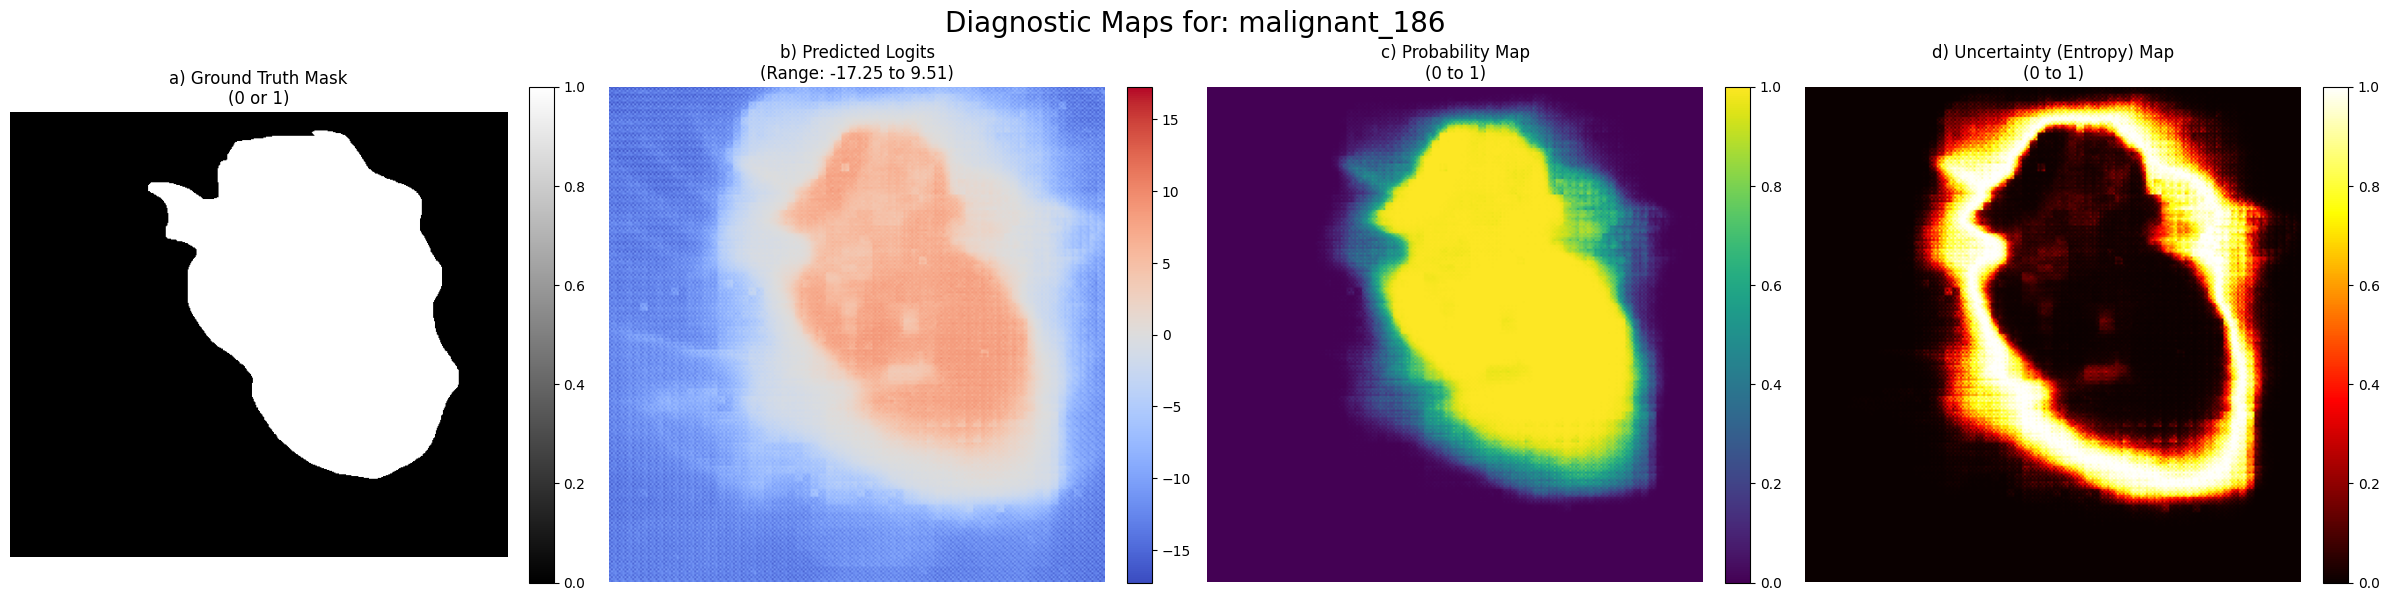

Visualizing samples:  50%|█████     | 1/2 [00:07<00:07,  7.41s/it]


--- Processing: malignant_187 ---
Running inference for Our Model (Adapter + U-BL)...
Individual sub-maps saved for malignant_187 in ./plots/
Combined diagnostic visualization saved to: ./plots/malignant_187_00000_diagnostic_combined.png


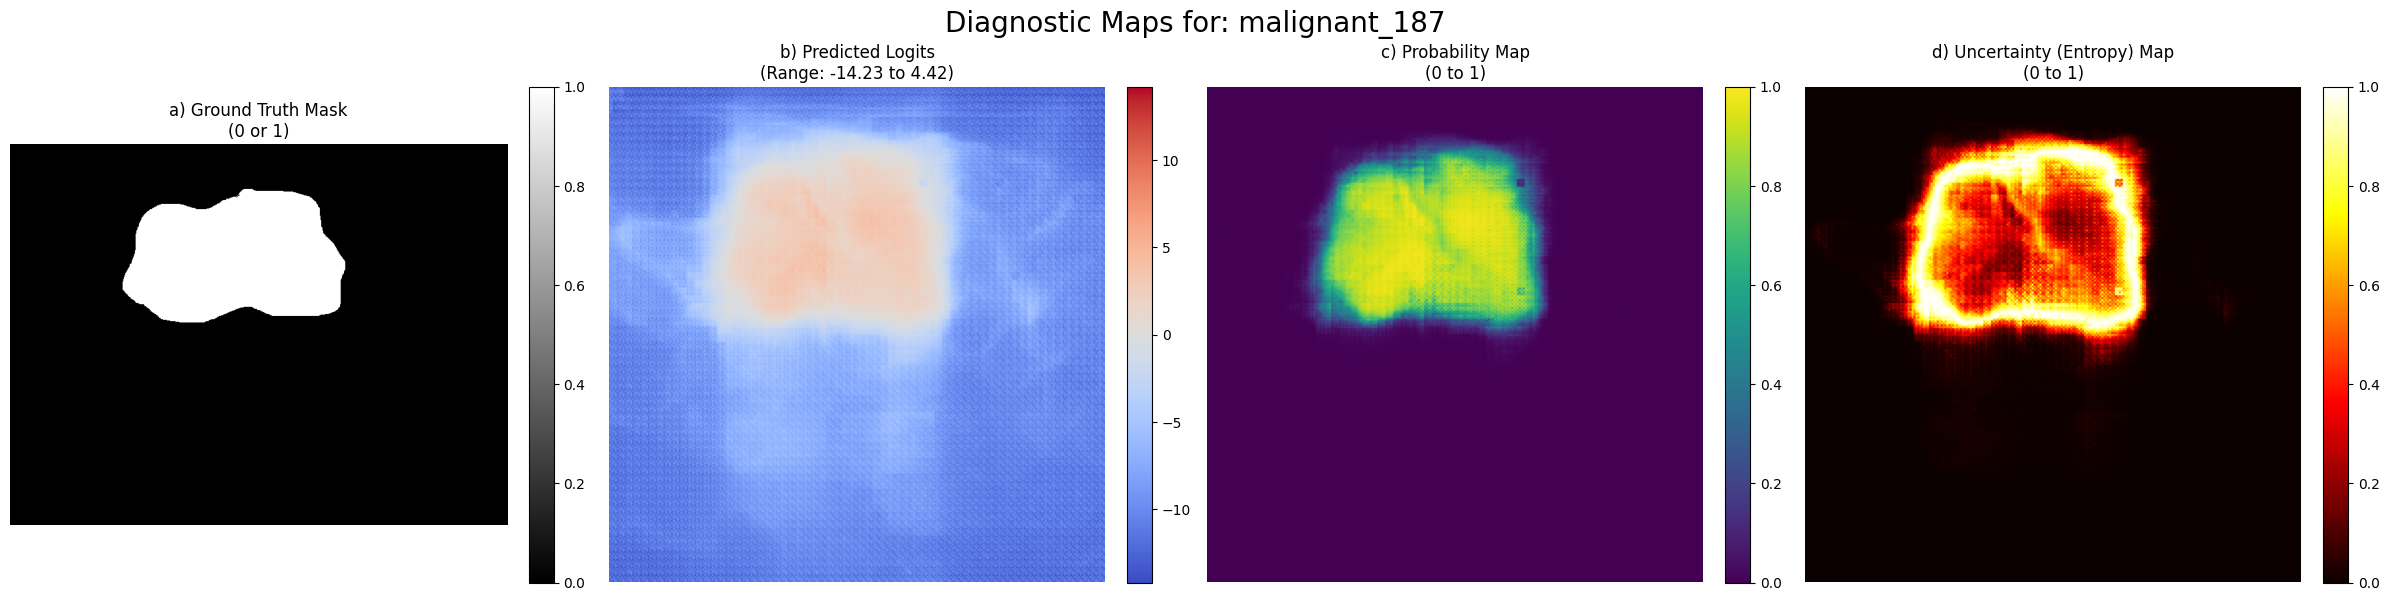

Visualizing samples: 100%|██████████| 2/2 [00:11<00:00,  5.91s/it]


Visualization process complete!


In [1]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from tqdm import tqdm

# ==============================================================================
# 关键：导入您需要的SAM2模型构建和预测工具
# ==============================================================================
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# ==============================================================================
# (新) 辅助函数，用于计算概率和熵
# ==============================================================================
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def calculate_entropy(p):
    p_clamped = np.clip(p, 1e-6, 1 - 1e-6)
    return -p_clamped * np.log2(p_clamped) - (1 - p_clamped) * np.log2(1 - p_clamped)

# ==============================================================================
# (修改) 我们需要的四联图绘图函数，增加单独保存子图功能
# ==============================================================================
def plot_diagnostic_maps(
    image_path,
    original_img_rgb,
    gt_mask,
    pred_logits,
    save_dir="./plots"
):
    """
    生成一张包含 GT、Logits、Probs、Entropy 的四联图，并单独保存每个子图。
    """
    # 1. 从 Logits 计算概率图和熵图
    probability_map = sigmoid(pred_logits)
    entropy_map = calculate_entropy(probability_map)
    
    # 确保保存目录存在
    os.makedirs(save_dir, exist_ok=True)
    
    # 提取样本名 (例如 'malignant_186') 以防止保存时文件名冲突
    sample_name = os.path.basename(os.path.dirname(image_path))
    base_filename = f"{sample_name}_{os.path.basename(image_path).replace('.jpg', '')}"
    
    # ==========================================================
    # 新增逻辑：单独保存每个子图
    # ==========================================================
    
    # (a) 真实掩码 (Ground Truth)
    gt_save_path = os.path.join(save_dir, f"{base_filename}_gt.png")
    plt.imsave(gt_save_path, gt_mask, cmap='gray')
    
    # (b) 预测的 Logits
    vmax = max(abs(pred_logits.min()), abs(pred_logits.max()), 5)
    logits_save_path = os.path.join(save_dir, f"{base_filename}_logits.png")
    plt.imsave(logits_save_path, pred_logits, cmap='coolwarm', vmin=-vmax, vmax=vmax)
    
    # (c) 概率图
    probs_save_path = os.path.join(save_dir, f"{base_filename}_probs.png")
    plt.imsave(probs_save_path, probability_map, cmap='viridis', vmin=0, vmax=1)
    
    # (d) 不确定性/熵图
    entropy_save_path = os.path.join(save_dir, f"{base_filename}_entropy.png")
    plt.imsave(entropy_save_path, entropy_map, cmap='hot', vmin=0, vmax=1)
    
    print(f"Individual sub-maps saved for {sample_name} in {save_dir}/")

    # ==========================================================
    # 原有逻辑：创建 1x4 的四联子图布局并保存
    # ==========================================================
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    fig.suptitle(f'Diagnostic Maps for: {sample_name}', fontsize=20)

    # (a) 真实掩码 (Ground Truth)
    im1 = axes[0].imshow(gt_mask, cmap='gray', vmin=0, vmax=1)
    axes[0].set_title('a) Ground Truth Mask\n(0 or 1)')
    axes[0].axis('off')
    fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

    # (b) 预测的 Logits
    im2 = axes[1].imshow(pred_logits, cmap='coolwarm', vmin=-vmax, vmax=vmax)
    axes[1].set_title(f'b) Predicted Logits\n(Range: {pred_logits.min():.2f} to {pred_logits.max():.2f})')
    axes[1].axis('off')
    fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

    # (c) 概率图
    im3 = axes[2].imshow(probability_map, cmap='viridis', vmin=0, vmax=1)
    axes[2].set_title('c) Probability Map\n(0 to 1)')
    axes[2].axis('off')
    fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

    # (d) 不确定性/熵图
    im4 = axes[3].imshow(entropy_map, cmap='hot', vmin=0, vmax=1)
    axes[3].set_title('d) Uncertainty (Entropy) Map\n(0 to 1)')
    axes[3].axis('off')
    fig.colorbar(im4, ax=axes[3], fraction=0.046, pad=0.04)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    
    # 保存四联图
    combined_save_path = os.path.join(save_dir, f"{base_filename}_diagnostic_combined.png")
    plt.savefig(combined_save_path, dpi=300, bbox_inches='tight')
    print(f"Combined diagnostic visualization saved to: {combined_save_path}")
    
    plt.show()
    plt.close()


# ==============================================================================
# (保留) 原始的对比图绘图函数 (这里保持不变)
# ==============================================================================
def plot_comparison(image_path, original_img_rgb, gt_mask, baseline_pred_mask, our_pred_mask, our_uncertainty_map, save_dir="visualizations"):
    # ... (这部分代码完全不变) ...
    # 为了简洁，此处省略，请保留您原来的代码
    # --- 创建2x3的子图布局 ---
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f'Qualitative Comparison for: {os.path.basename(image_path)}', fontsize=20)

    # --- 第一行：基础信息 ---
    # (a) 原始图像
    axes[0, 0].imshow(original_img_rgb)
    axes[0, 0].set_title("a) Original Image", fontsize=14)
    axes[0, 0].axis('off')

    # (b) 真实掩码 (Ground Truth)
    axes[0, 1].imshow(original_img_rgb)
    axes[0, 1].imshow(gt_mask, cmap='gray', alpha=0.7)
    axes[0, 1].set_title("b) Ground Truth", fontsize=14)
    axes[0, 1].axis('off')
    
    # (c) 您的模型的不确定性图
    im = axes[0, 2].imshow(our_uncertainty_map, cmap='jet')
    axes[0, 2].set_title("c) Our Model's Uncertainty Map", fontsize=14)
    axes[0, 2].axis('off')
    fig.colorbar(im, ax=axes[0, 2], fraction=0.046, pad=0.04)
    
    # ... (其余部分也保持不变) ...
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, os.path.basename(image_path).replace('.jpg', '_comparison_v2.png'))
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Comparison visualization saved to: {save_path}")
    plt.show()
    plt.close()

# ==============================================================================
# (修改) 推理函数，让它返回 logits
# ==============================================================================
def run_inference_on_image(model_checkpoint_path, image_path, mask_path):
    """
    加载一个指定的模型，对单张图片进行推理，并返回预测掩码和原始logits。
    """
    SAM2_CFG_NAME = "configs/sam2.1/sam2.1_hiera_b+"
    HYDRA_OVERRIDES = [
        "model.image_encoder.trunk._target_=sam2.modeling.backbones.hieradet_adapterv1.Hiera",
        "+model.image_encoder.trunk.use_adapter=True",
        "+model.use_adapter=True",
    ]
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = build_sam2(
        SAM2_CFG_NAME, 
        model_checkpoint_path,
        device=device,
        hydra_overrides_extra=HYDRA_OVERRIDES
    )
    predictor = SAM2ImagePredictor(model)
    
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    predictor.set_image(image_rgb)
    contours, _ = cv2.findContours(gt_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours: return None, None
    
    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)
    box_prompt = np.array([[x, y, x + w, y + h]])

    masks, scores, logits = predictor.predict(
        box=box_prompt,
        multimask_output=False
    )
    
    pred_mask_np = (masks[0] * 255).astype(np.uint8)
    
    # --- 核心修改：返回 logits ---
    pred_logits_np = logits[0] # logits 的形状已经是 (H, W)
    
    predictor.reset_predictor()
    
    return pred_mask_np, pred_logits_np


# ==============================================================================
# (修改) 主函数，增加调用四联图的逻辑
# ==============================================================================
def main():
    BASELINE_MODEL_CKPT = "/home/zhengsongming/jupyterworkspace/03医学图像分割/sam2_finetune_logs/busi_adapter_run2/checkpoints/checkpoint.pt"
    OUR_MODEL_CKPT = "/home/zhengsongming/jupyterworkspace/03医学图像分割/sam2_finetune_logs/busi_bLoss_adapter_run16/checkpoints/checkpoint.pt"

    SPLIT_DATASET_ROOT = "/home/zhengsongming/jupyterworkspace/datasets/BUSI_for_SAM2"
    
    SAMPLES_TO_VISUALIZE = [
        "malignant_186",
        "malignant_187",
    ]

    images_dir = os.path.join(SPLIT_DATASET_ROOT, "JPEGImages")
    annotations_dir = os.path.join(SPLIT_DATASET_ROOT, "Annotations")

    print("Starting visualization process...")
    for sample_name in tqdm(SAMPLES_TO_VISUALIZE, desc="Visualizing samples"):
        image_path = os.path.join(images_dir, sample_name, "00000.jpg")
        mask_path = os.path.join(annotations_dir, sample_name, "00000.png")

        if not os.path.exists(image_path):
            print(f"Warning: Image for {sample_name} not found, skipping.")
            continue
            
        print(f"\n--- Processing: {sample_name} ---")

        original_img_rgb = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
        gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # --- 为您的模型运行推理，获取 logits ---
        print("Running inference for Our Model (Adapter + U-BL)...")
        our_pred_mask, our_pred_logits = run_inference_on_image(OUR_MODEL_CKPT, image_path, mask_path)
        
        if our_pred_logits is None:
            print(f"Inference failed for {sample_name}, skipping.")
            continue

        # --- (新增) 调用新的绘图函数，生成四联图 ---
        plot_diagnostic_maps(
            image_path,
            original_img_rgb,
            gt_mask,
            our_pred_logits,
        )

    print("\nVisualization process complete!")


if __name__ == '__main__':
    main()